In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('FutureModelPredictionData.csv')
probs = pd.read_csv('Probabilities.csv')

df['Republican Prob'] = probs.mean(axis=1)
df

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,republican_incumbent,pvi,Republican Prob
0,2026,AL,1,27.72,41.1,4.0,63.8,26.1,0.5,1.6,True,True,True,27.0,0.994378
1,2026,AL,2,25.70,39.0,5.2,58.8,30.3,0.2,1.4,True,True,False,-5.0,0.024997
2,2026,AL,3,25.79,40.1,4.2,67.0,23.2,0.2,1.6,True,True,True,23.0,0.994423
3,2026,AL,4,20.50,40.8,8.1,80.6,6.3,0.3,0.8,True,True,True,33.0,0.994742
4,2026,AL,5,38.20,39.4,7.0,68.6,17.4,0.3,2.0,True,True,True,15.0,0.986759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2026,WI,5,41.55,43.0,6.0,85.9,1.8,0.1,3.0,True,True,True,11.0,0.971964
431,2026,WI,6,30.01,42.7,6.0,86.0,2.0,0.3,2.6,True,True,True,8.0,0.952464
432,2026,WI,7,26.71,45.3,3.0,89.4,0.4,1.6,1.5,True,True,True,11.0,0.972926
433,2026,WI,8,29.29,41.5,6.7,83.7,1.5,1.8,2.5,True,True,True,8.0,0.948987


## Simulating 2026 Outcomes

In [5]:
num_simulations = 50000
simulationDict = {
    'Republican Seats' : [],
    'Democratic Seats' : []
}
np.random.seed(28)

for _ in range(num_simulations):
    randomNum = np.random.rand()
    numWins = (df['Republican Prob'] > randomNum).sum()
    numLosses = 435 - numWins
    simulationDict['Republican Seats'].append(numWins)
    simulationDict['Democratic Seats'].append(numLosses)

simulationDF = pd.DataFrame(simulationDict)

winCount = (simulationDF['Republican Seats'] >= 218).sum()
republicanProb = (winCount/num_simulations) * 100
democraticProb = 100 - republicanProb

print("Democrats have a ", democraticProb, "% chance of flipping the House of Representatives.")
print("Republicans have a ", republicanProb, "% chance of holding the House of Representatives.")


Democrats have a  69.482 % chance of flipping the House of Representatives.
Republicans have a  30.518 % chance of holding the House of Representatives.


In [6]:
simulationDF['Margin'] = simulationDF['Republican Seats'] - simulationDF['Democratic Seats']
print('Democratic Mode: ', simulationDF['Democratic Seats'].mode())
print('Republican Mode: ',simulationDF['Republican Seats'].mode())
simulationDF.describe()
#simulationDF

Democratic Mode:  0    222
Name: Democratic Seats, dtype: int64
Republican Mode:  0    213
Name: Republican Seats, dtype: int64


,Republican Seats,Democratic Seats,Margin
count,50000.000000,50000.000000,50000.000000
mean,205.740760,229.259240,-23.518480
std,39.075833,39.075833,78.151665
min,0.000000,0.000000,-435.000000
25%,198.000000,211.000000,-39.000000
50%,211.000000,224.000000,-13.000000
75%,224.000000,237.000000,13.000000
max,435.000000,435.000000,435.000000


## Forecast Visualizations

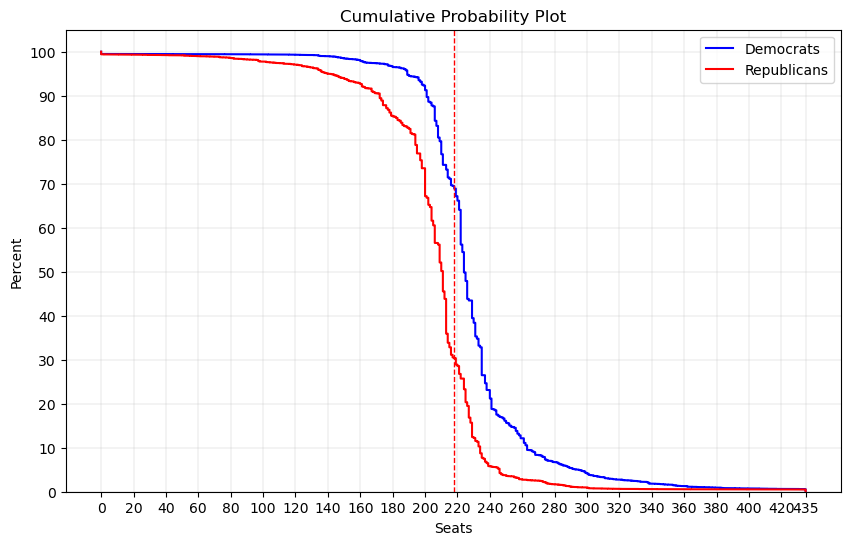

In [7]:
fig, ax = plt.subplots(figsize=(10,6))
sns.ecdfplot(data=simulationDF['Democratic Seats'], stat='percent', complementary=True, label= 'Democrats', color='blue', ax=ax)
sns.ecdfplot(data=simulationDF['Republican Seats'], stat='percent', complementary=True, label='Republicans', color='red', ax=ax)
ax.set_xticks([0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420,435])
ax.set_yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.title('Cumulative Probability Plot')
plt.xlabel('Seats')
plt.grid(True, linewidth = 0.2)
plt.legend()
plt.axvline(x=218, color='red', linestyle='--', linewidth=1)
plt.show()

(-100.0, 100.0)

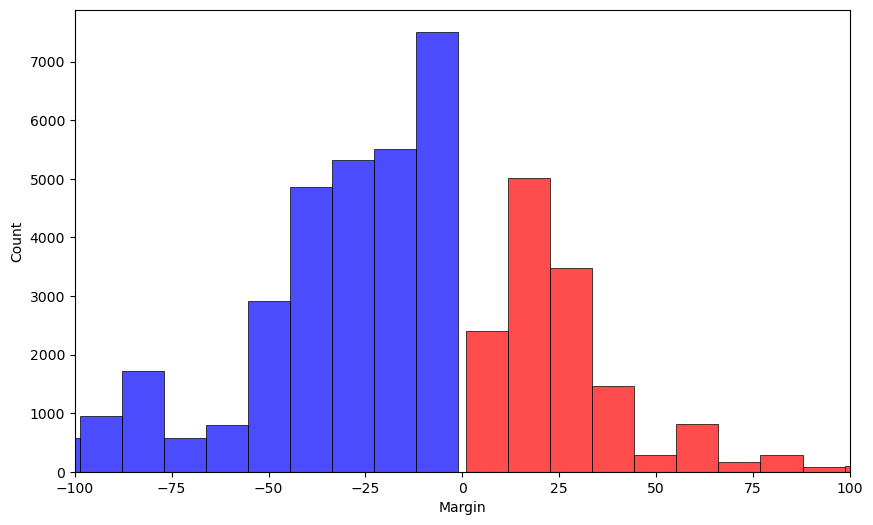

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
democraticMargin = simulationDF[simulationDF['Margin'] < 0]
republicanMargin = simulationDF[simulationDF['Margin'] > 0]
sns.histplot(data=democraticMargin['Margin'], bins=40, alpha=0.7, color='blue', linewidth=0.5)
sns.histplot(data=republicanMargin['Margin'], bins=40, alpha=0.7, color='red', linewidth=0.5)
plt.xlim(-100,100)

## District Ratings

In [15]:
filteredDF = df[(df['Republican Prob'] < 0.9) & (df['Republican Prob'] > 0.1)]
filteredDF = filteredDF.drop(['year', 'CollegeGrad', 'MedianAge', 'Hispanic', 'White', 'Black', 'NativeAmerican', 'Asian', 'republican_president', 'midterm'], axis=1)
filteredDF

,state_po,district,republican_incumbent,pvi,Republican Prob
7,AK,0,True,6.0,0.752933
8,AZ,1,True,1.0,0.357080
9,AZ,2,True,7.0,0.734665
13,AZ,6,True,0.0,0.436494
23,CA,3,True,2.0,0.520012
...,...,...,...,...,...
404,VA,2,True,0.0,0.310727
416,WA,3,False,2.0,0.268359
418,WA,5,True,5.0,0.888334
426,WI,1,True,2.0,0.671541


In [16]:
def rating(prob):
    if 0.1 <= prob < 0.25:
        return "Likely D"
    elif 0.25 <= prob < 0.4:
        return "Lean D"
    elif 0.4 <= prob < 0.5:
        return "Tilt D"
    elif 0.5 <= prob < 0.6:
        return "Tilt R"
    elif 0.6 <= prob < 0.75:
        return "Lean R"
    else:
        return "Likely R"

In [18]:
filteredDF['Rating'] = filteredDF['Republican Prob'].apply(rating)
filteredDF

,state_po,district,republican_incumbent,pvi,Republican Prob,Rating
7,AK,0,True,6.0,0.752933,Likely R
8,AZ,1,True,1.0,0.357080,Lean D
9,AZ,2,True,7.0,0.734665,Lean R
13,AZ,6,True,0.0,0.436494,Tilt D
23,CA,3,True,2.0,0.520012,Tilt R
...,...,...,...,...,...,...
404,VA,2,True,0.0,0.310727,Lean D
416,WA,3,False,2.0,0.268359,Lean D
418,WA,5,True,5.0,0.888334,Likely R
426,WI,1,True,2.0,0.671541,Lean R


In [19]:
ratingDF = filteredDF.drop(['pvi'], axis=1)
ratingDF['district'] = ratingDF['district'].astype(str)
ratingDF['District'] = ratingDF['state_po'] + '-' + ratingDF['district']
ratingDF = ratingDF.drop(['state_po', 'district'], axis=1)
ratingDF.to_csv('2026Ratings.csv', index=False)
ratingDF

,republican_incumbent,Republican Prob,Rating,District
7,True,0.752933,Likely R,AK-0
8,True,0.357080,Lean D,AZ-1
9,True,0.734665,Lean R,AZ-2
13,True,0.436494,Tilt D,AZ-6
23,True,0.520012,Tilt R,CA-3
...,...,...,...,...
404,True,0.310727,Lean D,VA-2
416,False,0.268359,Lean D,WA-3
418,True,0.888334,Likely R,WA-5
426,True,0.671541,Lean R,WI-1


In [20]:
safeD = df[df['Republican Prob'] <= 0.1]
safeD

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,republican_incumbent,pvi,Republican Prob
1,2026,AL,2,25.70,39.0,5.2,58.8,30.3,0.2,1.4,True,True,False,-5.0,0.024997
6,2026,AL,7,24.31,36.9,4.5,36.0,55.2,0.2,1.3,True,True,False,-13.0,0.005931
10,2026,AZ,3,20.61,31.5,62.6,19.4,11.0,1.2,2.2,True,True,False,-22.0,0.005388
11,2026,AZ,4,40.14,35.8,29.2,52.7,4.9,1.8,5.8,True,True,False,-4.0,0.017260
14,2026,AZ,7,22.29,34.1,60.3,28.6,3.5,2.5,1.8,True,True,False,-13.0,0.007141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,2026,WA,8,41.97,40.0,12.0,64.8,2.0,0.9,11.6,True,True,False,-3.0,0.034822
422,2026,WA,9,43.57,38.0,14.7,39.3,12.6,0.2,23.3,True,True,False,-22.0,0.004960
423,2026,WA,10,34.67,37.3,14.0,58.1,7.0,0.8,7.6,True,True,False,-9.0,0.007633
427,2026,WI,2,47.48,37.4,7.2,78.6,4.4,0.1,5.0,True,True,False,-21.0,0.005214


In [21]:
safeR = df[df['Republican Prob'] >= 0.9]
safeR

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,republican_incumbent,pvi,Republican Prob
0,2026,AL,1,27.72,41.1,4.0,63.8,26.1,0.5,1.6,True,True,True,27.0,0.994378
2,2026,AL,3,25.79,40.1,4.2,67.0,23.2,0.2,1.6,True,True,True,23.0,0.994423
3,2026,AL,4,20.50,40.8,8.1,80.6,6.3,0.3,0.8,True,True,True,33.0,0.994742
4,2026,AL,5,38.20,39.4,7.0,68.6,17.4,0.3,2.0,True,True,True,15.0,0.986759
5,2026,AL,6,39.23,39.8,6.9,68.1,19.5,0.1,1.8,True,True,True,20.0,0.973899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2026,WI,5,41.55,43.0,6.0,85.9,1.8,0.1,3.0,True,True,True,11.0,0.971964
431,2026,WI,6,30.01,42.7,6.0,86.0,2.0,0.3,2.6,True,True,True,8.0,0.952464
432,2026,WI,7,26.71,45.3,3.0,89.4,0.4,1.6,1.5,True,True,True,11.0,0.972926
433,2026,WI,8,29.29,41.5,6.7,83.7,1.5,1.8,2.5,True,True,True,8.0,0.948987
